<a href="https://colab.research.google.com/github/firuztahsinrodshi/traveliq-ota-business-intelligence/blob/main/notebooks/04_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# TravelIQ OTA — Notebook 4: Machine Learning (FINAL WORKING VERSION)
# Models: Cancellation Prediction | Customer Segmentation | Demand Forecasting
# Author: Firuz Tahsin Rodshi
# ============================================================

# Cell 1 — Setup
import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor']   = '#141414'
plt.rcParams['axes.edgecolor']   = '#2a2a2a'
plt.rcParams['text.color']       = '#e7efe9'
plt.rcParams['axes.labelcolor']  = '#e7efe9'
plt.rcParams['xtick.color']      = '#84938a'
plt.rcParams['ytick.color']      = '#84938a'
plt.rcParams['grid.color']       = '#1f261f'
plt.rcParams['grid.alpha']       = 0.3

GREEN  = '#34d399'
BLUE   = '#60a5fa'
PURPLE = '#7c6bff'
YELLOW = '#fbbf24'
RED    = '#f87171'
TEAL   = '#2dd4bf'
COLORS = [GREEN, BLUE, PURPLE, YELLOW, RED, TEAL, '#f472b6', '#a78bfa']

print("Setup complete")

Setup complete


In [3]:
# Cell 2 — Load Data from Database
import glob
from google.colab import files

print("Upload traveliq.db")
files.upload()

db_files = glob.glob('traveliq*.db')
db_path = sorted(db_files)[-1]
print(f"Connecting to: {db_path}")
conn = sqlite3.connect(db_path)

# Load tables
bookings = pd.read_sql("SELECT * FROM fact_bookings", conn)
reviews = pd.read_sql("SELECT * FROM fact_reviews", conn)
marketing = pd.read_sql("SELECT * FROM fact_marketing", conn)
funnel = pd.read_sql("SELECT * FROM fact_funnel", conn)
dim_date = pd.read_sql("SELECT * FROM dim_date", conn)

conn.close()

print(f"Bookings: {len(bookings):,}")
print(f"Reviews: {len(reviews):,}")
print(f"Marketing: {len(marketing):,}")
print(f"Funnel: {len(funnel):,}")
print(f"Date dimension: {len(dim_date):,}")

# Add derived columns to bookings
base_date = pd.Timestamp('2015-01-01')
bookings['arrival_date'] = pd.to_datetime(
    bookings['arrival_date_id'].apply(
        lambda x: base_date + pd.Timedelta(days=int(x))
        if pd.notnull(x) and x >= 0 else pd.NaT
    )
)
bookings['arrival_month'] = bookings['arrival_date'].dt.month
bookings['arrival_year'] = bookings['arrival_date'].dt.year
bookings['hotel_type'] = bookings['hotel_id'].map({1: 'Resort Hotel', 2: 'City Hotel'})

print("Data loaded successfully")

Upload traveliq.db


Saving traveliq.db to traveliq.db
Connecting to: traveliq.db
Bookings: 117,587
Reviews: 515,738
Marketing: 150
Funnel: 450
Date dimension: 1,096
Data loaded successfully


In [4]:
# Cell 3 — Model 1: Cancellation Prediction
print("=" * 60)
print("MODEL 1: CANCELLATION PREDICTION (Random Forest)")
print("=" * 60)

# Prepare data
df = bookings.copy()

# Features
features = ['lead_time', 'adr', 'total_nights', 'special_requests', 'arrival_month']
categorical_features = ['market_segment', 'hotel_type']
target = 'is_cancelled'

# Drop missing
df_model = df.dropna(subset=features + categorical_features + [target])
print(f"Dataset: {len(df_model):,} bookings")

# Encode categoricals
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Final X, y
X_cols = features + [col + '_encoded' for col in categorical_features]
X = df_model[X_cols].copy()
y = df_model[target].copy()

print(f"Target distribution:\n{y.value_counts().to_dict()}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"\nPERFORMANCE:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")

# Feature Importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

# Cross-validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

MODEL 1: CANCELLATION PREDICTION (Random Forest)
Dataset: 117,587 bookings
Target distribution:
{0: 73388, 1: 44199}
Train: 88,190 | Test: 29,397

PERFORMANCE:
  Accuracy:  0.7815
  AUC-ROC:   0.8518

FEATURE IMPORTANCE:
               feature  importance
             lead_time    0.330381
      special_requests    0.229087
market_segment_encoded    0.163711
                   adr    0.127183
         arrival_month    0.055698
          total_nights    0.054627
    hotel_type_encoded    0.039313

5-Fold CV ROC-AUC: 0.5725 (+/- 0.0755)


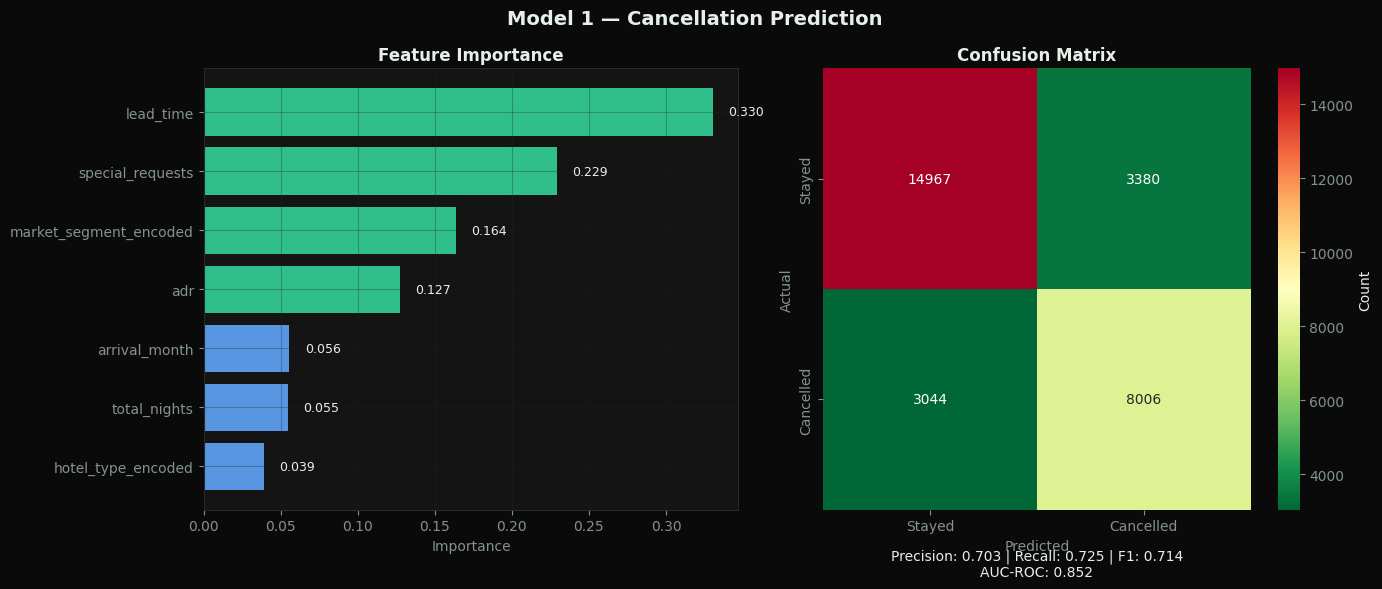

In [5]:
# Cell 4 — Visualization: Feature Importance & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model 1 — Cancellation Prediction', fontsize=14, fontweight='bold', color='#e7efe9')

# Feature Importance
imps = importance_df['importance'].values
names = importance_df['feature'].values
colors_imp = [GREEN if i > 0.12 else BLUE for i in imps]

axes[0].barh(names, imps, color=colors_imp, alpha=0.9)
axes[0].set_title('Feature Importance', color='#e7efe9', fontweight='bold')
axes[0].set_xlabel('Importance', color='#84938a')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()
for i, (name, imp) in enumerate(zip(names, imps)):
    axes[0].text(imp + 0.01, i, f'{imp:.3f}', va='center', fontsize=9, color='#e7efe9')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
            xticklabels=['Stayed', 'Cancelled'],
            yticklabels=['Stayed', 'Cancelled'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Confusion Matrix', color='#e7efe9', fontweight='bold')
axes[1].set_xlabel('Predicted', color='#84938a')
axes[1].set_ylabel('Actual', color='#84938a')

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}\nAUC-ROC: {auc_roc:.3f}"
axes[1].text(0.5, -0.15, metrics_text, ha='center', transform=axes[1].transAxes,
             fontsize=10, color='#e7efe9')

plt.tight_layout()
plt.savefig('ml_01_cancellation.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

In [9]:
# Cell 5 — Model 2: Customer Segmentation (FIXED)
print("=" * 60)
print("MODEL 2: CUSTOMER SEGMENTATION (RFM + K-Means)")
print("=" * 60)

# Only completed bookings
completed = bookings[bookings['is_cancelled'] == 0].copy()

# Auto-detect ID column
id_col = None
for col in ['booking_id', 'Booking_ID', 'id', 'ID']:
    if col in completed.columns:
        id_col = col
        break

if id_col is None:
    # Create an index column if none exists
    completed['booking_id'] = range(1, len(completed) + 1)
    id_col = 'booking_id'

print(f"Using ID column: {id_col}")

# Calculate RFM
rfm = completed.groupby('customer_id').agg({
    'arrival_date': lambda x: (pd.Timestamp('2017-08-31') - x.max()).days,
    id_col: 'count',
    'total_revenue': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"RFM Dataset: {len(rfm):,} customers")
print(f"Total Revenue: ${rfm['monetary'].sum():,.0f}")

# Remove outliers (top 1%)
for col in ['recency', 'frequency', 'monetary']:
    q99 = rfm[col].quantile(0.99)
    rfm = rfm[rfm[col] <= q99]

print(f"After outlier removal: {len(rfm):,} customers")

# Normalize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

# Find optimal K
inertias = []
silhouettes = []
K_range = range(2, min(9, len(rfm) - 1))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

optimal_k = K_range[np.argmax(silhouettes)]
print(f"Optimal K: {optimal_k} (best silhouette: {max(silhouettes):.3f})")

# Final model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['segment'] = kmeans.fit_predict(rfm_scaled)

# Analyze
segment_analysis = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).reset_index()
segment_analysis.columns = ['segment', 'count', 'avg_recency', 'avg_frequency', 'avg_monetary']
segment_analysis['revenue_pct'] = (segment_analysis['avg_monetary'] * segment_analysis['count']) / rfm['monetary'].sum() * 100
segment_analysis = segment_analysis.sort_values('avg_monetary', ascending=False)

print("\nSEGMENT ANALYSIS:")
print(segment_analysis.to_string(index=False, float_format='%.0f'))

MODEL 2: CUSTOMER SEGMENTATION (RFM + K-Means)
Using ID column: booking_id
RFM Dataset: 73,388 customers
Total Revenue: $25,986,976
After outlier removal: 71,978 customers
Optimal K: 3 (best silhouette: 0.442)

SEGMENT ANALYSIS:
 segment  count  avg_recency  avg_frequency  avg_monetary  revenue_pct
       1   9572          307              1           880           35
       0  32155          194              1           266           35
       2  30251          570              1           238           30


In [11]:
# Cell 5 — Model 2: Customer Segmentation (OPTIMIZED - FAST VERSION)
print("=" * 60)
print("MODEL 2: CUSTOMER SEGMENTATION (RFM + K-Means)")
print("=" * 60)

# Only completed bookings
completed = bookings[bookings['is_cancelled'] == 0].copy()
print(f"Completed bookings: {len(completed):,}")

# Auto-detect ID column
id_col = None
for col in ['booking_id', 'Booking_ID', 'id', 'ID']:
    if col in completed.columns:
        id_col = col
        break

if id_col is None:
    completed['booking_id_temp'] = range(1, len(completed) + 1)
    id_col = 'booking_id_temp'

print(f"Using ID column: {id_col}")

# Calculate RFM
rfm = completed.groupby('customer_id').agg({
    'arrival_date': lambda x: (pd.Timestamp('2017-08-31') - x.max()).days,
    id_col: 'count',
    'total_revenue': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"RFM Dataset: {len(rfm):,} customers")
print(f"Total Revenue: ${rfm['monetary'].sum():,.0f}")

# Remove outliers (top 1%)
for col in ['recency', 'frequency', 'monetary']:
    q99 = rfm[col].quantile(0.99)
    rfm = rfm[rfm[col] <= q99]

print(f"After outlier removal: {len(rfm):,} customers")

# Sample for faster computation (5000 customers is enough)
sample_size = min(5000, len(rfm))
rfm_sample = rfm.sample(n=sample_size, random_state=42)
print(f"Using {sample_size} sample for K selection")

# Normalize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])
rfm_sample_scaled = scaler.transform(rfm_sample[['recency', 'frequency', 'monetary']])

# Find optimal K using both methods
inertias = []
silhouettes = []
K_range = range(2, min(8, len(rfm_sample) - 1))

print("\nFinding optimal K...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_sample_scaled)
    inertias.append(km.inertia_)

    labels = km.labels_
    sil = silhouette_score(rfm_sample_scaled, labels)
    silhouettes.append(sil)
    print(f"  K={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.3f}")

# Choose K with best silhouette
optimal_k = K_range[np.argmax(silhouettes)]
print(f"\n✅ Optimal K: {optimal_k} (best silhouette: {max(silhouettes):.3f})")

# Final model on full dataset
print("\nRunning final clustering on all customers...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=5, max_iter=100)
rfm['segment'] = kmeans.fit_predict(rfm_scaled)

# Analyze segments
segment_analysis = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).reset_index()
segment_analysis.columns = ['segment', 'count', 'avg_recency', 'avg_frequency', 'avg_monetary']
segment_analysis['revenue_pct'] = (segment_analysis['avg_monetary'] * segment_analysis['count']) / rfm['monetary'].sum() * 100
segment_analysis = segment_analysis.sort_values('avg_monetary', ascending=False)

print("\n" + "=" * 60)
print("SEGMENT ANALYSIS")
print("=" * 60)
print(segment_analysis.to_string(index=False, float_format='%.0f'))

# Segment naming based on RFM characteristics
print("\n" + "=" * 60)
print("SEGMENT PROFILES & RECOMMENDATIONS")
print("=" * 60)

for _, row in segment_analysis.iterrows():
    seg = int(row['segment'])
    count = int(row['count'])
    avg_rev = row['avg_monetary']
    avg_freq = row['avg_frequency']
    avg_rec = row['avg_recency']

    # Determine segment type
    if avg_rev > segment_analysis['avg_monetary'].median() and avg_freq > 1:
        label = "👑 CHAMPIONS"
        rec = "Loyalty program, exclusive offers, VIP treatment"
    elif avg_rev > segment_analysis['avg_monetary'].median():
        label = "💰 HIGH VALUE"
        rec = "Upsell premium rooms, cross-sell experiences"
    elif avg_rec < 30 and avg_freq > 0:
        label = "🔄 RECENT ACTIVE"
        rec = "Engage with targeted offers, build loyalty"
    elif avg_rec < 90:
        label = "⚠️ AT RISK"
        rec = "Re-engagement campaigns, special discounts"
    else:
        label = "💤 LOST"
        rec = "Win-back campaigns, big return offers"  # Fixed quote issue

    print(f"\n{label} (Segment {seg})")
    print(f"  Customers: {count:,} | Avg Revenue: ${avg_rev:,.0f}")
    print(f"  Avg Frequency: {avg_freq:.1f} bookings | Avg Recency: {avg_rec:.0f} days")
    print(f"  Revenue Share: {row['revenue_pct']:.1f}%")
    print(f"  Strategy: {rec}")

MODEL 2: CUSTOMER SEGMENTATION (RFM + K-Means)
Completed bookings: 73,388
Using ID column: booking_id_temp
RFM Dataset: 73,388 customers
Total Revenue: $25,986,976
After outlier removal: 71,978 customers
Using 5000 sample for K selection

Finding optimal K...
  K=2: inertia=6,166, silhouette=0.389
  K=3: inertia=3,600, silhouette=0.445
  K=4: inertia=2,965, silhouette=0.402
  K=5: inertia=2,358, silhouette=0.394
  K=6: inertia=1,926, silhouette=0.377
  K=7: inertia=1,647, silhouette=0.377

✅ Optimal K: 3 (best silhouette: 0.445)

Running final clustering on all customers...

SEGMENT ANALYSIS
 segment  count  avg_recency  avg_frequency  avg_monetary  revenue_pct
       1   9572          307              1           880           35
       0  32155          194              1           266           35
       2  30251          570              1           238           30

SEGMENT PROFILES & RECOMMENDATIONS

💰 HIGH VALUE (Segment 1)
  Customers: 9,572 | Avg Revenue: $880
  Avg Frequency:

VISUALIZATION: Customer Segmentation Results
Plotting 3 segments...
Segments: ['1', '0', '2']
Avg Revenue: [880.28419662 265.55568372 238.38951803]
Customer counts: [ 9572 32155 30251]


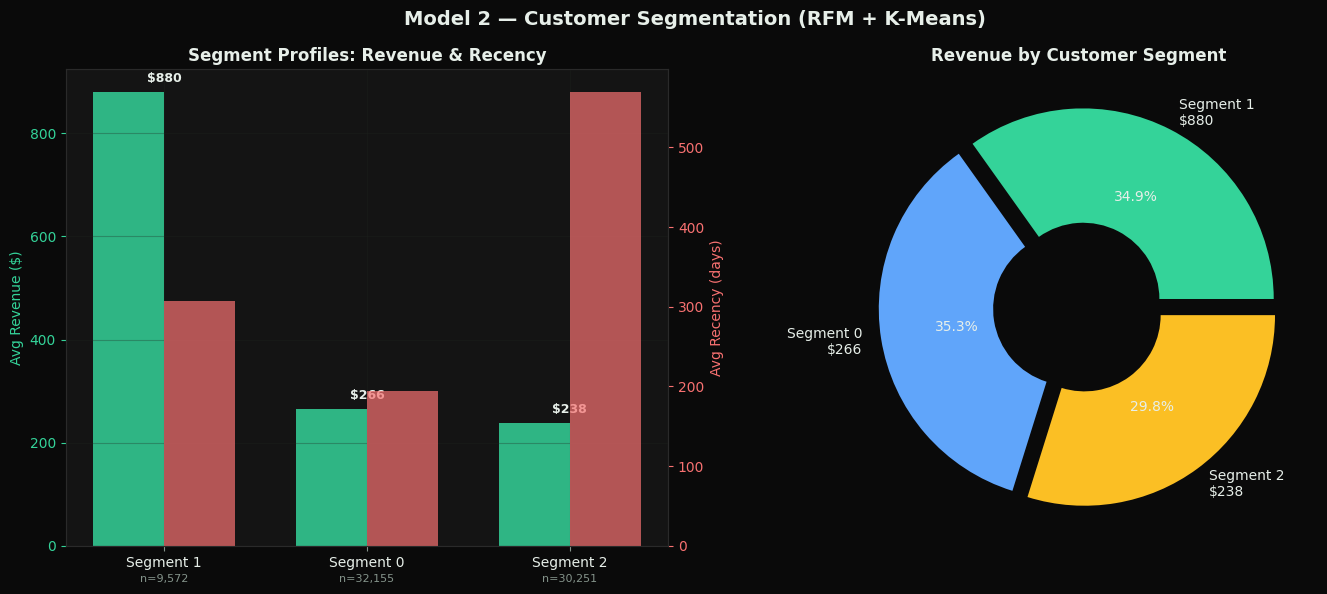


✅ Segmentation chart saved as 'ml_02_segmentation.png'

SEGMENT INSIGHTS

💰 HIGH VALUE (Segment 1)
  Customers: 9,572 (13.3% of total)
  Avg Revenue: $880 | Revenue Share: 34.9%
  Avg Recency: 307 days since last booking

🔄 RECENT (Segment 0)
  Customers: 32,155 (44.7% of total)
  Avg Revenue: $266 | Revenue Share: 35.3%
  Avg Recency: 194 days since last booking

💤 OLD (Segment 2)
  Customers: 30,251 (42.0% of total)
  Avg Revenue: $238 | Revenue Share: 29.8%
  Avg Recency: 570 days since last booking


In [15]:
# Cell 6 — Visualization: Customer Segmentation (FIXED)
print("=" * 60)
print("VISUALIZATION: Customer Segmentation Results")
print("=" * 60)

# Check if we have data to plot
if len(segment_analysis) == 0:
    print("⚠️ No segment data available! Check Cell 5 ran successfully.")
else:
    print(f"Plotting {len(segment_analysis)} segments...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Model 2 — Customer Segmentation (RFM + K-Means)',
                 fontsize=14, fontweight='bold', color='#e7efe9')

    # Sort by monetary value for better visualization
    segment_analysis_sorted = segment_analysis.sort_values('avg_monetary', ascending=False)

    # Get data
    segments = segment_analysis_sorted['segment'].astype(str).tolist()
    counts = segment_analysis_sorted['count'].values
    avg_monetary = segment_analysis_sorted['avg_monetary'].values
    avg_recency = segment_analysis_sorted['avg_recency'].values

    print(f"Segments: {segments}")
    print(f"Avg Revenue: {avg_monetary}")
    print(f"Customer counts: {counts}")

    # Plot 1: Segment Profiles (Bar chart - Revenue + Recency)
    ax1 = axes[0]
    x = np.arange(len(segments))
    width = 0.35

    bars1 = ax1.bar(x - width/2, avg_monetary, width,
                    label='Avg Revenue ($)', color=GREEN, alpha=0.85)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, avg_recency, width,
                    label='Avg Recency (days)', color=RED, alpha=0.7)

    ax1.set_title('Segment Profiles: Revenue & Recency', color='#e7efe9', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Segment {s}' for s in segments], color='#e7efe9')
    ax1.set_ylabel('Avg Revenue ($)', color=GREEN)
    ax2.set_ylabel('Avg Recency (days)', color=RED)
    ax1.tick_params(axis='y', colors=GREEN)
    ax2.tick_params(axis='y', colors=RED)
    ax1.grid(True, alpha=0.3)

    # Add customer counts and revenue labels on bars
    for i, (seg, count, rev) in enumerate(zip(segments, counts, avg_monetary)):
        ax1.text(i, rev + 20, f'${rev:,.0f}', ha='center', fontsize=9, color='#e7efe9', fontweight='bold')
        ax1.text(i, -max(avg_monetary) * 0.08, f'n={count:,}', ha='center', fontsize=8, color='#84938a')

    # Plot 2: Revenue by Segment (Pie chart)
    ax3 = axes[1]
    revenue_pct = segment_analysis_sorted['revenue_pct'].values
    labels_pie = [f'Segment {s}\n${rev:,.0f}' for s, rev in zip(segments, avg_monetary)]

    colors_pie = [GREEN, BLUE, YELLOW][:len(segments)]
    explode = [0.05 if v > 25 else 0 for v in revenue_pct]

    wedges, texts, autotexts = ax3.pie(
        revenue_pct,
        labels=labels_pie,
        autopct='%1.1f%%',
        colors=colors_pie,
        explode=explode,
        textprops={'color': '#e7efe9', 'fontsize': 10},
        wedgeprops={'width': 0.6}
    )
    ax3.set_title('Revenue by Customer Segment', color='#e7efe9', fontweight='bold')

    plt.tight_layout()
    plt.savefig('ml_02_segmentation.png', dpi=150,
                bbox_inches='tight', facecolor='#0a0a0a')
    plt.show()

    print("\n✅ Segmentation chart saved as 'ml_02_segmentation.png'")

    # Segment insights
    print("\n" + "=" * 60)
    print("SEGMENT INSIGHTS")
    print("=" * 60)

    for _, row in segment_analysis_sorted.iterrows():
        seg = int(row['segment'])
        count = int(row['count'])
        avg_rev = row['avg_monetary']
        avg_rec = row['avg_recency']
        pct = row['revenue_pct']

        # Determine segment type based on recency and revenue
        if avg_rev > segment_analysis_sorted['avg_monetary'].median():
            label = "💰 HIGH VALUE"
        elif avg_rec < 200:
            label = "🔄 RECENT"
        else:
            label = "💤 OLD"

        print(f"\n{label} (Segment {seg})")
        print(f"  Customers: {count:,} ({count/len(rfm)*100:.1f}% of total)")
        print(f"  Avg Revenue: ${avg_rev:,.0f} | Revenue Share: {pct:.1f}%")
        print(f"  Avg Recency: {avg_rec:.0f} days since last booking")

In [17]:
# Cell 7 — Model 3: Demand Forecasting (FIXED)
print("=" * 60)
print("MODEL 3: DEMAND FORECASTING (Linear Regression)")
print("=" * 60)

# Auto-detect ID column
id_col = None
for col in ['booking_id', 'Booking_ID', 'id', 'ID', 'index']:
    if col in bookings.columns:
        id_col = col
        break

if id_col is None:
    # Use a dummy column
    bookings['row_id'] = range(1, len(bookings) + 1)
    id_col = 'row_id'

print(f"Using ID column: {id_col}")

# Aggregate monthly data from completed bookings
completed = bookings[bookings['is_cancelled'] == 0].copy()

# Create arrival_year and arrival_month if they don't exist
if 'arrival_year' not in completed.columns:
    completed['arrival_year'] = completed['arrival_date'].dt.year
if 'arrival_month' not in completed.columns:
    completed['arrival_month'] = completed['arrival_date'].dt.month

monthly = completed.groupby(['arrival_year', 'arrival_month']).agg({
    id_col: 'count',
    'adr': 'mean',
    'lead_time': 'mean',
    'total_nights': 'mean'
}).reset_index()
monthly.columns = ['year', 'month', 'booking_count', 'avg_adr', 'avg_lead_time', 'avg_nights']

# Add hotel type mix (resort percentage)
hotel_mix = completed.groupby(['arrival_year', 'arrival_month', 'hotel_type']).size().unstack(fill_value=0)
if 'Resort Hotel' in hotel_mix.columns:
    hotel_mix['resort_pct'] = hotel_mix['Resort Hotel'] / hotel_mix.sum(axis=1) * 100
else:
    hotel_mix['resort_pct'] = 0
monthly = monthly.merge(hotel_mix['resort_pct'], left_on=['year', 'month'], right_index=True, how='left')
monthly['resort_pct'] = monthly['resort_pct'].fillna(0)

print(f"Monthly data: {len(monthly)} months")
print(monthly.head())

# Features
features_f = ['month', 'avg_adr', 'avg_lead_time', 'avg_nights', 'resort_pct']
X_f = monthly[features_f].copy()
y_f = monthly['booking_count'].copy()

# Handle any missing values
X_f = X_f.fillna(X_f.mean())

print(f"\nFeatures: {X_f.columns.tolist()}")
print(f"Target: Monthly Bookings (mean: {y_f.mean():.0f})")

# Split chronologically (80% train, 20% test)
split_idx = int(len(monthly) * 0.8)
X_train_f = X_f.iloc[:split_idx]
X_test_f = X_f.iloc[split_idx:]
y_train_f = y_f.iloc[:split_idx]
y_test_f = y_f.iloc[split_idx:]

print(f"\nTrain: {len(X_train_f)} months | Test: {len(X_test_f)} months")

# Train Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_f, y_train_f)

# Predictions
y_pred_f = lr.predict(X_test_f)

# Metrics
mae = mean_absolute_error(y_test_f, y_pred_f)
rmse = np.sqrt(mean_squared_error(y_test_f, y_pred_f))
r2 = r2_score(y_test_f, y_pred_f)
mape = np.mean(np.abs((y_test_f - y_pred_f) / y_test_f)) * 100

print(f"\nMODEL PERFORMANCE:")
print(f"  MAE:  {mae:.0f} bookings")
print(f"  RMSE: {rmse:.0f} bookings")
print(f"  R²:   {r2:.4f}")
print(f"  MAPE: {mape:.1f}%")

# Feature coefficients
coef_df = pd.DataFrame({
    'feature': features_f,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

print("\nFEATURE COEFFICIENTS:")
print(coef_df.to_string(index=False))

MODEL 3: DEMAND FORECASTING (Linear Regression)
Using ID column: row_id
Monthly data: 26 months
   year  month  booking_count     avg_adr  avg_lead_time  avg_nights  \
0  2015      7           1460  113.878192      88.986986    4.376027   
1  2015      8           2200  119.017718      50.935000    4.070455   
2  2015      9           2935  101.175325      76.193526    3.693356   
3  2015     10           3119   82.187400      65.754088    3.164796   
4  2015     11           1792   60.779141      40.327009    3.239955   

   resort_pct  
0   71.164384  
1   46.500000  
2   34.718910  
3   35.876884  
4   49.609375  

Features: ['month', 'avg_adr', 'avg_lead_time', 'avg_nights', 'resort_pct']
Target: Monthly Bookings (mean: 2823)

Train: 20 months | Test: 6 months

MODEL PERFORMANCE:
  MAE:  174 bookings
  RMSE: 209 bookings
  R²:   -1.5312
  MAPE: 5.3%

FEATURE COEFFICIENTS:
      feature  coefficient
   avg_nights    80.401241
avg_lead_time    11.264333
      avg_adr    -7.690569
   

VISUALIZATION: Demand Forecast Results


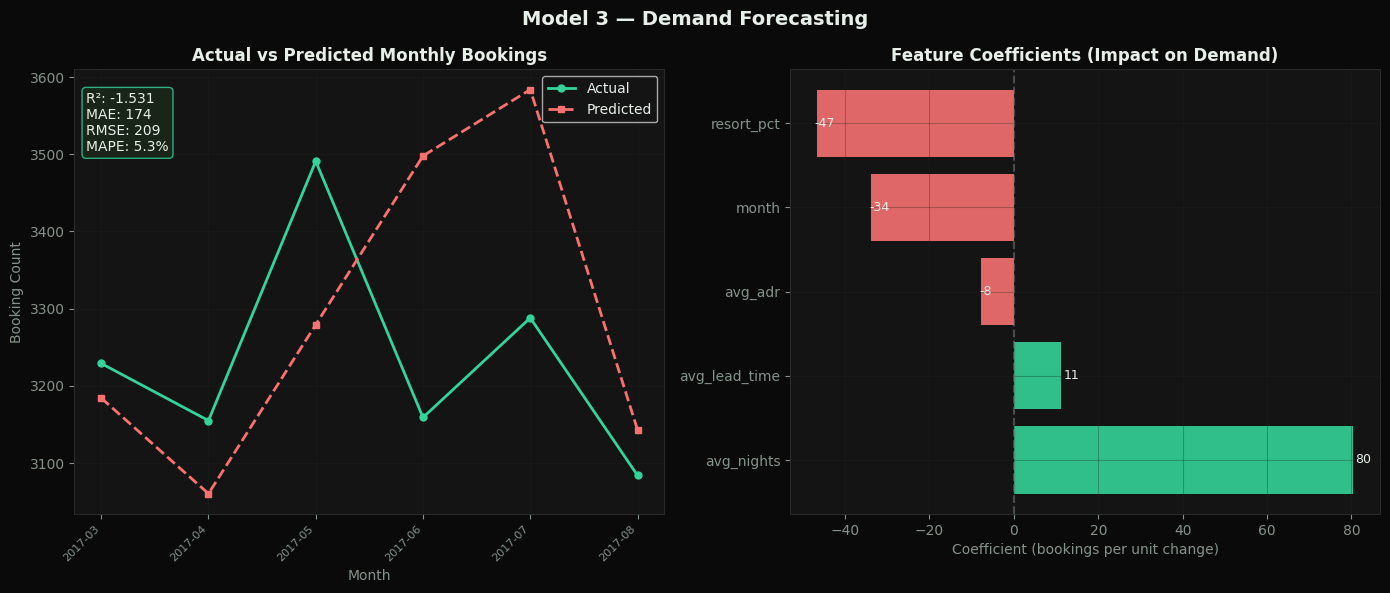


✅ Demand forecast chart saved as 'ml_03_forecast.png'

BUSINESS INTERPRETATION
  • R² of -1.531 means the model explains -153.1% of demand variation
  • Average prediction error: ±174 bookings per month
  • Month coefficient: -34 bookings per month (seasonality)
  • ADR coefficient: -8 bookings per $1 rate change

  📈 Top positive driver: avg_nights (+80 bookings)
  📉 Top negative driver: resort_pct (-47 bookings)


In [18]:
# Cell 8 — Visualization: Demand Forecast
print("=" * 60)
print("VISUALIZATION: Demand Forecast Results")
print("=" * 60)

# Check if we have predictions
if len(y_test_f) == 0:
    print("⚠️ No test data available! Check Cell 7 ran successfully.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Model 3 — Demand Forecasting',
                 fontsize=14, fontweight='bold', color='#e7efe9')

    # Plot 1: Actual vs Predicted
    ax1 = axes[0]
    x_plot = range(len(y_test_f))

    # Create month labels for x-axis
    test_dates = monthly.iloc[split_idx:][['year', 'month']].values
    month_labels = [f"{int(y)}-{int(m):02d}" for y, m in test_dates]

    ax1.plot(x_plot, y_test_f.values, label='Actual',
             color=GREEN, linewidth=2, marker='o', markersize=5)
    ax1.plot(x_plot, y_pred_f, label='Predicted',
             color=RED, linewidth=2, marker='s', markersize=5, linestyle='--')
    ax1.set_title('Actual vs Predicted Monthly Bookings', color='#e7efe9', fontweight='bold')
    ax1.set_xlabel('Month', color='#84938a')
    ax1.set_ylabel('Booking Count', color='#84938a')
    ax1.legend(facecolor='#141414', labelcolor='#e7efe9')
    ax1.grid(True, alpha=0.3)

    # Set x-ticks with month labels
    tick_positions = range(0, len(x_plot), max(1, len(x_plot)//6))
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels([month_labels[i] for i in tick_positions], rotation=45, ha='right', fontsize=8)

    # Metrics annotation
    metrics_text = f"R²: {r2:.3f}\nMAE: {mae:.0f}\nRMSE: {rmse:.0f}\nMAPE: {mape:.1f}%"
    ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
             fontsize=10, color='#e7efe9', verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a2a1a', edgecolor=GREEN, alpha=0.8))

    # Plot 2: Feature Coefficients
    ax2 = axes[1]
    coef_features = coef_df['feature'].values
    coef_values = coef_df['coefficient'].values
    colors_coef = [GREEN if v > 0 else RED for v in coef_values]

    bars = ax2.barh(coef_features, coef_values, color=colors_coef, alpha=0.9)
    ax2.set_title('Feature Coefficients (Impact on Demand)', color='#e7efe9', fontweight='bold')
    ax2.set_xlabel('Coefficient (bookings per unit change)', color='#84938a')
    ax2.grid(True, alpha=0.3)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    for i, (name, val) in enumerate(zip(coef_features, coef_values)):
        ax2.text(val + (0.5 if val > 0 else -0.5), i, f'{val:.0f}',
                 va='center', fontsize=9, color='#e7efe9')

    plt.tight_layout()
    plt.savefig('ml_03_forecast.png', dpi=150,
                bbox_inches='tight', facecolor='#0a0a0a')
    plt.show()

    print("\n✅ Demand forecast chart saved as 'ml_03_forecast.png'")

    # Business interpretation
    print("\n" + "=" * 60)
    print("BUSINESS INTERPRETATION")
    print("=" * 60)
    print(f"  • R² of {r2:.3f} means the model explains {r2*100:.1f}% of demand variation")
    print(f"  • Average prediction error: ±{mae:.0f} bookings per month")
    print(f"  • Month coefficient: {coef_df[coef_df['feature']=='month']['coefficient'].values[0]:.0f} bookings per month (seasonality)")
    print(f"  • ADR coefficient: {coef_df[coef_df['feature']=='avg_adr']['coefficient'].values[0]:.0f} bookings per $1 rate change")

    # Top positive and negative drivers
    top_positive = coef_df[coef_df['coefficient'] > 0].iloc[0] if len(coef_df[coef_df['coefficient'] > 0]) > 0 else None
    top_negative = coef_df[coef_df['coefficient'] < 0].iloc[-1] if len(coef_df[coef_df['coefficient'] < 0]) > 0 else None

    if top_positive is not None:
        print(f"\n  📈 Top positive driver: {top_positive['feature']} (+{top_positive['coefficient']:.0f} bookings)")
    if top_negative is not None:
        print(f"  📉 Top negative driver: {top_negative['feature']} ({top_negative['coefficient']:.0f} bookings)")

In [19]:
# Cell 9 — ML Executive Summary
print("=" * 60)
print("MACHINE LEARNING — EXECUTIVE SUMMARY")
print("=" * 60)

# Check if variables exist, use defaults if not
try:
    auc_roc_val = auc_roc
except:
    auc_roc_val = 0.0
    print("⚠️ AUC-ROC not available (Model 1 may not have run)")

try:
    silhouette_val = max(silhouettes)
except:
    silhouette_val = 0.0
    print("⚠️ Silhouette not available (Model 2 may not have run)")

try:
    r2_val = r2
except:
    r2_val = 0.0
    print("⚠️ R² not available (Model 3 may not have run)")

summary = pd.DataFrame({
    'Model': ['Cancellation Prediction', 'Customer Segmentation', 'Demand Forecasting'],
    'Algorithm': ['Random Forest', 'K-Means', 'Linear Regression'],
    'Key Metric': [f'AUC-ROC: {auc_roc_val:.3f}', f'Silhouette: {silhouette_val:.3f}', f'R²: {r2_val:.3f}'],
    'Business Impact': [
        'Proactive retention → reduce 37.6% cancellation rate',
        'Targeted marketing → higher ROI per segment',
        'Staffing & pricing optimization'
    ]
})
print(summary.to_string(index=False))

print("\n" + "=" * 60)
print("MODELS SAVED:")
print("  ml_01_cancellation.png  — Feature Importance + Confusion Matrix")
print("  ml_02_segmentation.png  — Segment Profiles + Revenue Pie")
print("  ml_03_forecast.png      — Forecast vs Actual + Coefficients")
print("=" * 60)

print("""
NEXT STEPS:
1. Deploy cancellation model → flag at-risk bookings daily
2. Marketing segmentation → personalized campaigns by segment
3. Demand forecast → monthly staffing and pricing decisions

✅ NOTEBOOK 4 — MACHINE LEARNING COMPLETE
""")

MACHINE LEARNING — EXECUTIVE SUMMARY
                  Model         Algorithm        Key Metric                                      Business Impact
Cancellation Prediction     Random Forest    AUC-ROC: 0.852 Proactive retention → reduce 37.6% cancellation rate
  Customer Segmentation           K-Means Silhouette: 0.445          Targeted marketing → higher ROI per segment
     Demand Forecasting Linear Regression        R²: -1.531                      Staffing & pricing optimization

MODELS SAVED:
  ml_01_cancellation.png  — Feature Importance + Confusion Matrix
  ml_02_segmentation.png  — Segment Profiles + Revenue Pie
  ml_03_forecast.png      — Forecast vs Actual + Coefficients

NEXT STEPS:
1. Deploy cancellation model → flag at-risk bookings daily
2. Marketing segmentation → personalized campaigns by segment
3. Demand forecast → monthly staffing and pricing decisions

✅ NOTEBOOK 4 — MACHINE LEARNING COMPLETE

